# Methods meteorology figures - 17.07.2026

1. Discharge
2. Precipitation and potential evapotranspiration (PET)
3. Climate change perturbed meteorology (precip and PET)

In [1]:
# Install required packages
import pandas as pd
from pathlib import Path    
import os                      
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# Discharge (Q)

In [2]:
# Load observed discharge data
q = pd.read_csv("../Data/Cal&Val/daily_discharge_0531.txt", sep="\t")

q["Time"] = pd.to_datetime(q["Time"])
q = q.set_index("Time")
print(q.head())

            Shiplaw_Burn  Middle_Burn  Middle_Longcote  Kidston_Mill
Time                                                                
2011-03-22         0.016        0.012            0.025         0.942
2011-03-23         0.014        0.011            0.023         0.841
2011-03-24         0.012        0.010            0.022         0.760
2011-03-25         0.006        0.010            0.020         0.709
2011-03-26         0.004        0.009            0.020         0.667


In [3]:
# Computing monhtly regimes
q_regime = q.groupby(q.index.month).mean()

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

q_regime.index = month_names

In [4]:
# Create regimes of monthly discharge
def create_regime(df_name):
    return pd.DataFrame({
        "Discharge": q.groupby(q.index.month)[df_name].mean(),
    })

regimes_SB = create_regime("Shiplaw_Burn")
regimes_MB = create_regime("Middle_Burn")
regimes_ML = create_regime("Middle_Longcote")
regimes_KM = create_regime("Kidston_Mill")

for df in [regimes_SB, regimes_MB, regimes_ML, regimes_KM]:
    df.index = month_names

In [5]:
# Re-order for the hydrological year (starting in September)
calendar_months = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]

hydro_months = ["Sep","Oct","Nov","Dec","Jan","Feb",
                "Mar","Apr","May","Jun","Jul","Aug"]

MB_discharge_regimes = regimes_MB.reindex(hydro_months)
SB_discharge_regimes = regimes_SB.reindex(hydro_months)
ML_discharge_regimes = regimes_ML.reindex(hydro_months)
KM_discharge_regimes = regimes_KM.reindex(hydro_months)

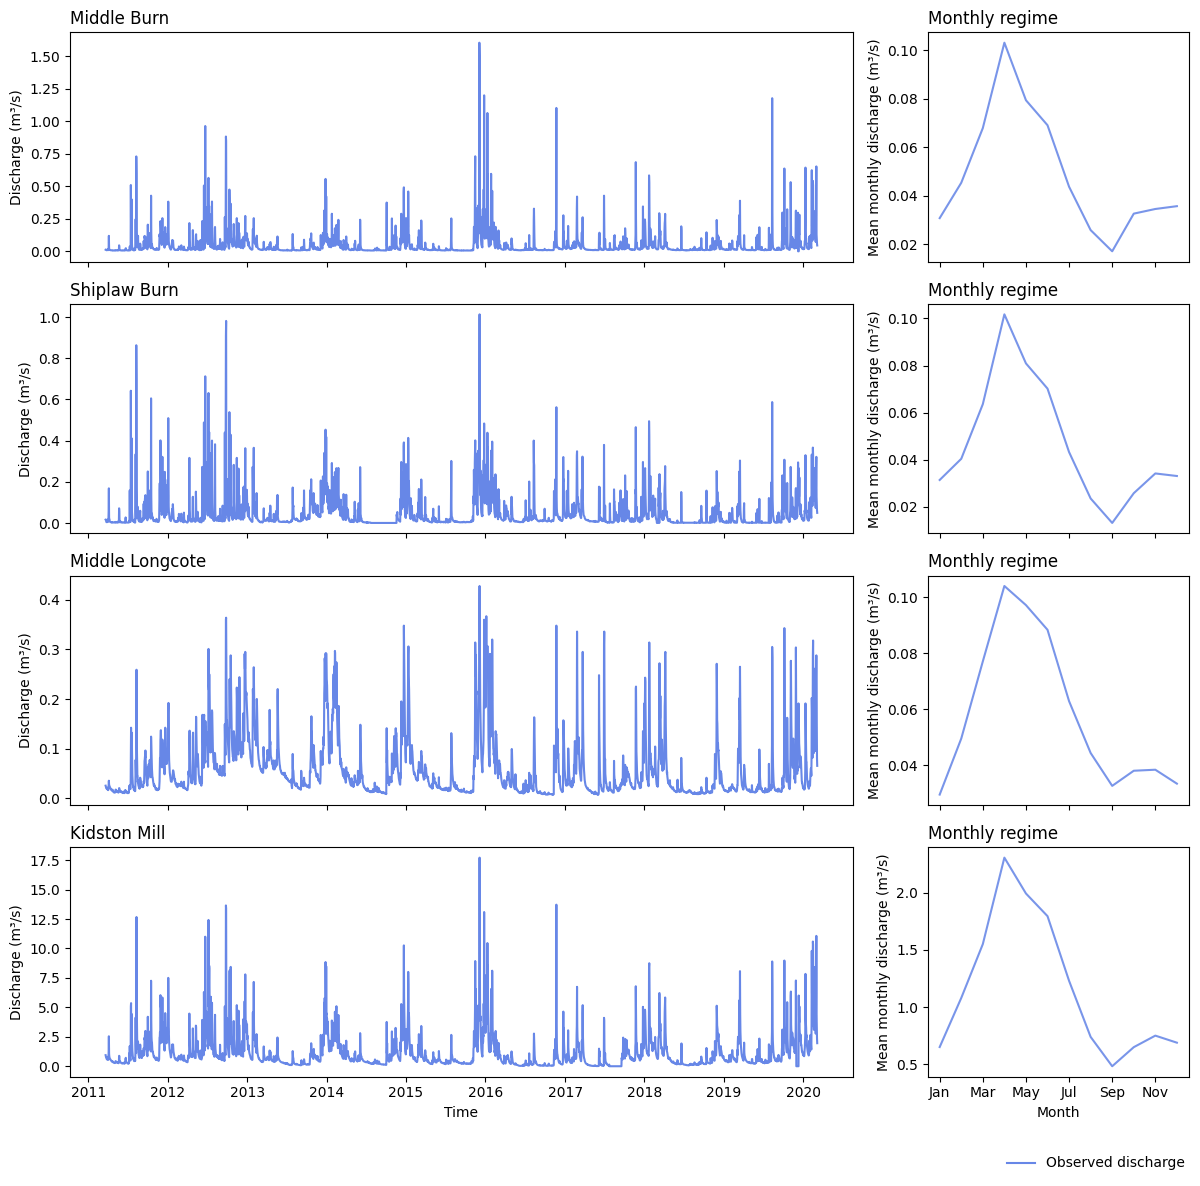

In [23]:
# Plot discharge for all 4 stations as timeseries and monthly regimes

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 12),
    gridspec_kw={"width_ratios": [3, 1]},
    sharex='col'
)

axes = axes.reshape(4, 2)

gauges = ["Middle_Burn", "Shiplaw_Burn", "Middle_Longcote", "Kidston_Mill"]
regimes = [MB_discharge_regimes, SB_discharge_regimes, ML_discharge_regimes, KM_discharge_regimes]

# Plotting loop
for i, gauge in enumerate(gauges):

    # Left: timeseries
    ax_ts = axes[i, 0]
    ax_ts.plot(q.index, q[gauge], alpha=0.8, color="royalblue", label="Observed discharge")
    ax_ts.set_title(gauge.replace("_", " "), loc="left")
    ax_ts.set_ylabel("Discharge (m³/s)")

    # Right: regime
    ax_reg = axes[i, 1]
    regimes[i].plot(ax=ax_reg, alpha=0.7, color="royalblue")
    ax_reg.set_title("Monthly regime", loc="left")
    ax_reg.set_ylabel("Mean monthly discharge (m³/s)")
    ax_reg.grid(False)


# Tick formatting
# Yearly ticks on the left column
for i in range(4):
    ax = axes[i, 0]
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(ticker.NullLocator())

# Monthly ticks on the right column
tick_labels    = ["Jan", "Mar", "May", "Jul", "Sep", "Nov"]
for i in range(4):
    ax = axes[i, 1]  # right column only
    ax.set_xticks([0, 2, 4, 6, 8, 10])
    ax.set_xticklabels(tick_labels)
    ax.xaxis.set_minor_locator(ticker.NullLocator())

# Bottom x‑labels
axes[3, 0].set_xlabel("Time")
axes[3, 1].set_xlabel("Month")

# Shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove the individual labels
for row in axes:
    for ax in row:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.91, 0.01), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("../Figures/Figure23.png", dpi=300, bbox_inches="tight")
plt.show()

## Observed rainfall and PET

In [8]:
# Load met data: Precip, PET
precip = pd.read_csv("../Data/Methods/daily_rainfall_0605.txt", sep="\\t")
precip["Time"] = pd.to_datetime(precip["Time"])
precip = precip.set_index("Time")

pet = pd.read_csv("../Data/Methods/daily_evapo_0605.txt", sep="\\t")
pet["Time"] = pd.to_datetime(pet["Time"])
pet = pet.set_index("Time")

/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_40498/3424072410.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  precip = pd.read_csv("../Data/Methods/daily_rainfall_0605.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_40498/3424072410.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  pet = pd.read_csv("../Data/Methods/daily_evapo_0605.txt", sep="\\t")


In [9]:
# Generate annual totals for precipitation (for study site chapter)
annual_precip = precip.groupby(precip.index.year).sum()
annual_precip.index.name = "year"
annual_precip["Mean"] = annual_precip.mean(axis=1)

print(annual_precip)

      Darnhall  Shiplaw  Burnhead  Craigburn      Mean
year                                                  
2011    1011.8   1040.0     991.8      912.3   988.975
2012    1467.9   1475.7    1429.0     1651.8  1506.100
2013     909.0    895.0     913.8      858.6   894.100
2014    1047.2    999.4    1142.4      944.6  1033.400
2015    1135.0   1194.6    1099.0      893.7  1080.575
2016    1072.9    944.0    1105.7      746.3   967.225
2017    1040.0    929.6    1014.6      785.3   942.375
2018     935.7    855.2     868.1      801.6   865.150
2019    1070.2   1037.6    1009.2     1014.9  1032.975
2020     338.2    338.0     426.2      358.2   365.150


In [10]:
# Generate monthly regime data for climate data
calendar_months = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"]

#precip_regime = precip.groupby(precip.index.month).mean()
#precip_regime.index = calendar_months

def create_regime(df_name):
    return pd.DataFrame({
        "Precip": precip.groupby(precip.index.month)[df_name].mean(),
    })

regimes_D = create_regime("Darnhall")
regimes_S = create_regime("Shiplaw")
regimes_B = create_regime("Burnhead")
regimes_C = create_regime("Craigburn")

for df in [regimes_D, regimes_S, regimes_B, regimes_C]:
    df.index = month_names

In [11]:
# Reorder months to match the hydrological year
hydro_months = ["Sep","Oct","Nov","Dec","Jan","Feb",
                "Mar","Apr","May","Jun","Jul","Aug"]

D_precip_regime = regimes_D.reindex(hydro_months)
S_precip_regime = regimes_S.reindex(hydro_months)
B_precip_regime = regimes_B.reindex(hydro_months)
C_precip_regime = regimes_C.reindex(hydro_months)

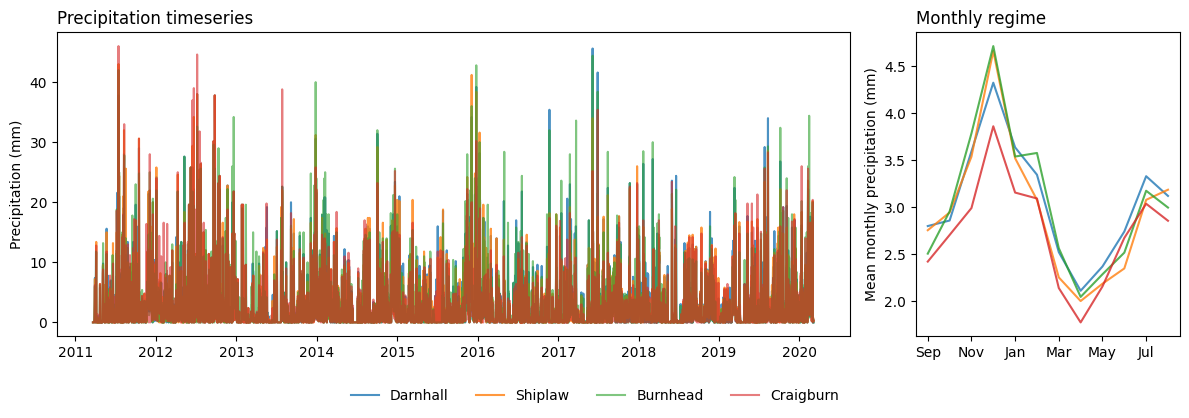

In [12]:
# Plot precip timeseries and regimes

# Create station colour dictionary
colour_dict = {
    "Darnhall": "#1f77b4",
    "Shiplaw":  "#ff7f0e",
    "Burnhead": "#2ca02c",
    "Craigburn": "#d62728"
}

# Plot 
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [3, 1]},
    sharex=False
)

ax_ts, ax_reg = axes

stations = ["Darnhall", "Shiplaw", "Burnhead", "Craigburn"]

for station in stations:
    alpha = 0.6 if station in ["Burnhead", "Craigburn"] else 0.8
    ax_ts.plot(
        precip.index,
        precip[station],
        label=station,
        color=colour_dict[station],
        alpha=alpha
    )

ax_ts.set_title("Precipitation timeseries", loc="left")
ax_ts.set_ylabel("Precipitation (mm)")

regimes = {
    "Darnhall": D_precip_regime,
    "Shiplaw": S_precip_regime,
    "Burnhead": B_precip_regime,
    "Craigburn": C_precip_regime
}

for station in stations:
    ax_reg.plot(
        regimes[station].index,
        regimes[station]["Precip"],
        color=colour_dict[station],
        alpha=0.8,
        label=station
    )

ax_reg.set_title("Monthly regime", loc="left")
ax_reg.set_ylabel("Mean monthly precipitation (mm)")
ax_reg.grid(False)

ax_ts.xaxis.set_major_locator(mdates.YearLocator())
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_ts.xaxis.set_minor_locator(ticker.NullLocator())

ax_reg.set_xticks([0, 2, 4, 6, 8, 10])
ax_reg.set_xticklabels(["Sep", "Nov", "Jan", "Mar", "May", "Jul"])
ax_reg.xaxis.set_minor_locator(ticker.NullLocator())

handles, labels = ax_ts.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("../Figures/Figure22a.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# PET
# Create monthly regime and reorder months to match the hydrological year
calendar_months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                   "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

hydro_months = ["Sep", "Oct", "Nov", "Dec", "Jan", "Feb",
                "Mar", "Apr", "May", "Jun", "Jul", "Aug"]

pet_regime = pd.DataFrame({
    "PET": pet.groupby(pet.index.month)[pet.columns[0]].mean(),
})
pet_regime.index = calendar_months
pet_regime_reordered = pet_regime.reindex(hydro_months)

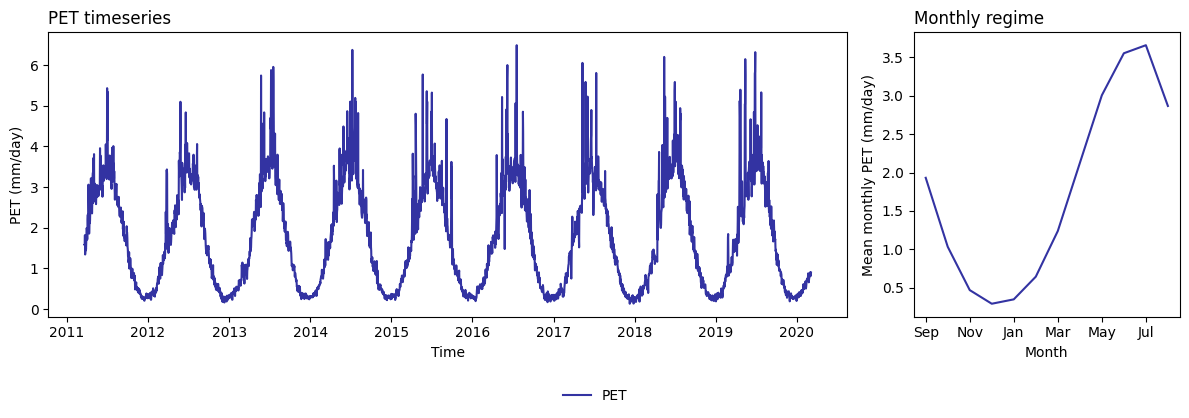

In [14]:
# PET figure 

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    gridspec_kw={"width_ratios": [3, 1]},
    sharex=False
)

ax_ts, ax_reg = axes

# Timeseries
ax_ts.plot(
    pet.index,
    pet[[pet.columns[0]]],
    label="PET",
    color="darkblue",
    alpha=0.8
)
ax_ts.set_title("PET timeseries", loc="left")
ax_ts.set_ylabel("PET (mm/day)")

# Regime
ax_reg.plot(
    pet_regime_reordered.index,
    pet_regime_reordered.values,
    color="darkblue",
    alpha=0.8,
    label="PET"
)
ax_reg.set_title("Monthly regime", loc="left")
ax_reg.set_ylabel("Mean monthly PET (mm/day)")
ax_reg.grid(False)

# Formatting
ax_ts.xaxis.set_major_locator(mdates.YearLocator())
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_ts.xaxis.set_minor_locator(ticker.NullLocator())

ax_reg.set_xticks([0, 2, 4, 6, 8, 10])
ax_reg.set_xticklabels(["Sep", "Nov", "Jan", "Mar", "May", "Jul"])
ax_reg.xaxis.set_minor_locator(ticker.NullLocator())

ax_ts.set_xlabel("Time")
ax_reg.set_xlabel("Month")

handles, labels = ax_ts.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=1, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.savefig("../Figures/Figure22b.png", dpi=300, bbox_inches="tight")
plt.show()


## Climate change perturbed met data regimes

In [15]:
# Load perturbed met data

# Perturbed precipitation
precip_2050_45 = pd.read_csv("../Data/Methods/Rainfall_2050_4.5_50.txt", sep="\t")
precip_2050_45["Time"] = pd.to_datetime(precip_2050_45["Time"])
precip_2050_45 = precip_2050_45.set_index("Time")

precip_2050_85 = pd.read_csv("../Data/Methods/Rainfall_2050_8.5_50.txt", sep="\t")
precip_2050_85["Time"] = pd.to_datetime(precip_2050_85["Time"])
precip_2050_85 = precip_2050_85.set_index("Time")

precip_2080_45 = pd.read_csv("../Data/Methods/Rainfall_2080_4.5_50.txt", sep="\t")
precip_2080_45["Time"] = pd.to_datetime(precip_2080_45["Time"])
precip_2080_45 = precip_2080_45.set_index("Time")

precip_2080_85 = pd.read_csv("../Data/Methods/Rainfall_2080_8.5_50.txt", sep="\t")
precip_2080_85["Time"] = pd.to_datetime(precip_2080_85["Time"])
precip_2080_85 = precip_2080_85.set_index("Time")

# Perturbed PET
pet_2050_45 = pd.read_csv("../Data/Methods/Evap_2050_4.5_50.txt", sep="\t")
pet_2050_45["Time"] = pd.to_datetime(pet_2050_45["Time"])
pet_2050_45 = pet_2050_45.set_index("Time")

pet_2050_85 = pd.read_csv("../Data/Methods/Evap_2050_8.5_50.txt", sep="\t")
pet_2050_85["Time"] = pd.to_datetime(pet_2050_85["Time"])
pet_2050_85 = pet_2050_85.set_index("Time")

pet_2080_45 = pd.read_csv("../Data/Methods/Evap_2080_4.5_50.txt", sep="\t")
pet_2080_45["Time"] = pd.to_datetime(pet_2080_45["Time"])
pet_2080_45 = pet_2080_45.set_index("Time")

pet_2080_85 = pd.read_csv("../Data/Methods/Evap_2080_8.5_50.txt", sep="\t")
pet_2080_85["Time"] = pd.to_datetime(pet_2080_85["Time"])
pet_2080_85 = pet_2080_85.set_index("Time")

In [16]:
# Monthly regimes for perturbed precipitation

def create_regime(df, column_name, value_name=None):
    if value_name is None:
        value_name = column_name

    regime = (
        df.groupby(df.index.month)[column_name]
          .mean()
          .rename(index=lambda month: calendar_months[month - 1])
          .to_frame(value_name)
    )
    return regime

stations = ["Darnhall", "Shiplaw", "Burnhead", "Craigburn"]

og_D = create_regime(precip, "Darnhall", "Precip")
og_S = create_regime(precip, "Shiplaw", "Precip")
og_B = create_regime(precip, "Burnhead", "Precip")
og_C = create_regime(precip, "Craigburn", "Precip")

# Create regime tables for RCP scenarios
precip_2050_45_regimes = {station: create_regime(precip_2050_45, station, "Precip") for station in stations}
precip_2050_85_regimes = {station: create_regime(precip_2050_85, station, "Precip") for station in stations}
precip_2080_45_regimes = {station: create_regime(precip_2080_45, station, "Precip") for station in stations}
precip_2080_85_regimes = {station: create_regime(precip_2080_85, station, "Precip") for station in stations}

In [18]:
# Reorder months to match the hydrological year
def reorder_months(df):
    return df.reindex(hydro_months)

D_precip_og = reorder_months(og_D)
S_precip_og = reorder_months(og_S)
B_precip_og = reorder_months(og_B)
C_precip_og = reorder_months(og_C)

D_p_2050_45 = reorder_months(precip_2050_45_regimes["Darnhall"])
S_p_2050_45 = reorder_months(precip_2050_45_regimes["Shiplaw"])
B_p_2050_45 = reorder_months(precip_2050_45_regimes["Burnhead"])
C_p_2050_45 = reorder_months(precip_2050_45_regimes["Craigburn"])

D_p_2050_85 = reorder_months(precip_2050_85_regimes["Darnhall"])
S_p_2050_85 = reorder_months(precip_2050_85_regimes["Shiplaw"])
B_p_2050_85 = reorder_months(precip_2050_85_regimes["Burnhead"])
C_p_2050_85 = reorder_months(precip_2050_85_regimes["Craigburn"])

D_p_2080_45 = reorder_months(precip_2080_45_regimes["Darnhall"])
S_p_2080_45 = reorder_months(precip_2080_45_regimes["Shiplaw"])
B_p_2080_45 = reorder_months(precip_2080_45_regimes["Burnhead"])
C_p_2080_45 = reorder_months(precip_2080_45_regimes["Craigburn"])

D_p_2080_85 = reorder_months(precip_2080_85_regimes["Darnhall"])
S_p_2080_85 = reorder_months(precip_2080_85_regimes["Shiplaw"])
B_p_2080_85 = reorder_months(precip_2080_85_regimes["Burnhead"])
C_p_2080_85 = reorder_months(precip_2080_85_regimes["Craigburn"])

In [19]:
# Merge the dataframes for each station into a single dataframe for each scenario
baseline = pd.concat([
    D_precip_og.rename(columns={"Precip": "Darnhall"}),
    S_precip_og.rename(columns={"Precip": "Shiplaw"}),
    B_precip_og.rename(columns={"Precip": "Burnhead"}),
    C_precip_og.rename(columns={"Precip": "Craigburn"})
], axis=1)

rcp45_2050 = pd.concat([
    D_p_2050_45.rename(columns={"Precip": "Darnhall"}),
    S_p_2050_45.rename(columns={"Precip": "Shiplaw"}),
    B_p_2050_45.rename(columns={"Precip": "Burnhead"}),
    C_p_2050_45.rename(columns={"Precip": "Craigburn"})
], axis=1)

rcp85_2050 = pd.concat([
    D_p_2050_85.rename(columns={"Precip": "Darnhall"}),
    S_p_2050_85.rename(columns={"Precip": "Shiplaw"}),
    B_p_2050_85.rename(columns={"Precip": "Burnhead"}),
    C_p_2050_85.rename(columns={"Precip": "Craigburn"})
], axis=1)


rcp45_2080 = pd.concat([
    D_p_2080_45.rename(columns={"Precip": "Darnhall"}),
    S_p_2080_45.rename(columns={"Precip": "Shiplaw"}),
    B_p_2080_45.rename(columns={"Precip": "Burnhead"}),
    C_p_2080_45.rename(columns={"Precip": "Craigburn"})
], axis=1)

rcp85_2080 = pd.concat([
    D_p_2080_85.rename(columns={"Precip": "Darnhall"}),
    S_p_2080_85.rename(columns={"Precip": "Shiplaw"}),
    B_p_2080_85.rename(columns={"Precip": "Burnhead"}),
    C_p_2080_85.rename(columns={"Precip": "Craigburn"})
], axis=1)

In [20]:
# PET regimes

# Baseline monthly regime for PET
pet_regime = pd.DataFrame({
    "ET": pet.groupby(pet.index.month)['ET'].mean(),
})
pet_regime.index = calendar_months

# Monthly regime under RCP scenarios
pet_2080_45_regime = pd.DataFrame({
    "ET": pet_2080_45.groupby(pet_2080_45.index.month)['ET'].mean(),
})
pet_2080_45_regime.index = calendar_months

pet_2080_85_regime = pd.DataFrame({
    "ET": pet_2080_85.groupby(pet_2080_85.index.month)['ET'].mean(),
})
pet_2080_85_regime.index = calendar_months

#2050s
pet_2050_45_regime = pd.DataFrame({
    "ET": pet_2050_45.groupby(pet_2050_45.index.month)['ET'].mean(),
})
pet_2050_45_regime.index = calendar_months

pet_2050_85_regime = pd.DataFrame({
    "ET": pet_2050_85.groupby(pet_2050_85.index.month)['ET'].mean(),
})
pet_2050_85_regime.index = calendar_months

In [21]:
# Reorder months to match the hydrological year
pet_regime = pet_regime.reindex(hydro_months)
pet_2050_45_regime = pet_2050_45_regime.reindex(hydro_months)
pet_2050_85_regime = pet_2050_85_regime.reindex(hydro_months)
pet_2080_45_regime = pet_2080_45_regime.reindex(hydro_months)
pet_2080_85_regime = pet_2080_85_regime.reindex(hydro_months)

/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_40498/1989749667.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


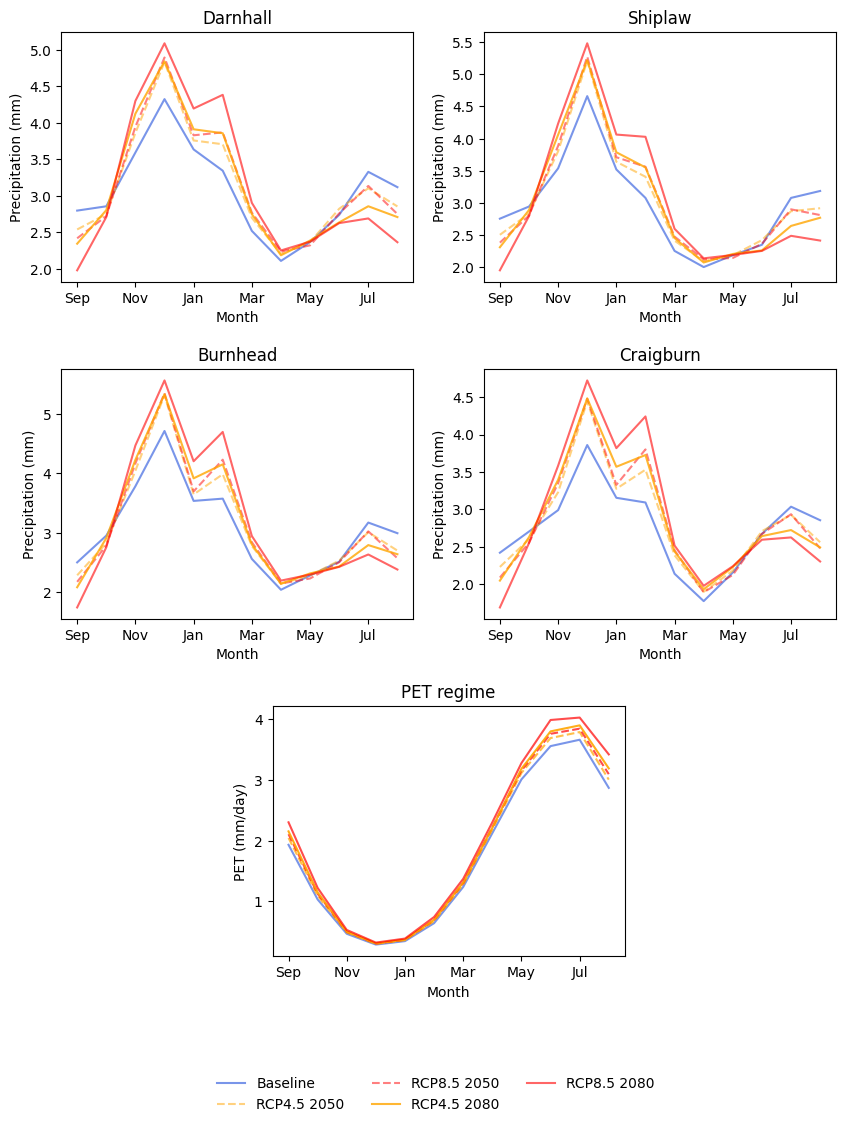

In [22]:
# Plot regimes for each station and scenario, with a PET plot in a third row

stations = ["Darnhall", "Shiplaw", "Burnhead", "Craigburn"]

fig = plt.figure(figsize=(10, 12))
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 1], width_ratios=[1, 1, 1, 1], hspace=0.35, wspace=0.5)
axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[1, 0:2]),
    fig.add_subplot(gs[1, 2:4]),
]
pet_ax = fig.add_subplot(gs[2, 1:3])

for i, station in enumerate(stations):
    ax = axes[i]

    ax.plot(
        baseline.index,
        baseline[station],
        label="Baseline",
        color="royalblue",
        alpha=0.7,
    )
    ax.plot(
        rcp45_2050.index,
        rcp45_2050[station],
        label="RCP4.5 2050",
        color="orange",
        linestyle="dashed",
        alpha=0.5,
    )
    ax.plot(
        rcp85_2050.index,
        rcp85_2050[station],
        label="RCP8.5 2050",
        color="red",
        linestyle="dashed",
        alpha=0.5,
    )
    ax.plot(
        rcp45_2080.index,
        rcp45_2080[station],
        label="RCP4.5 2080",
        color="orange",
        alpha=0.8,
    )
    ax.plot(
        rcp85_2080.index,
        rcp85_2080[station],
        label="RCP8.5 2080",
        color="red",
        alpha=0.6,
    )

    ax.set_title(station)
    ax.set_ylabel("Precipitation (mm)")
    if i >= 0:
        ax.set_xlabel("Month")
        ax.set_xticks([0, 2, 4, 6, 8, 10])
        ax.set_xticklabels(["Sep", "Nov", "Jan", "Mar", "May", "Jul"])
        ax.xaxis.set_minor_locator(ticker.NullLocator())


pet_ax.plot(
    pet_regime.index,
    pet_regime["ET"],
    color="royalblue",
    alpha=0.7,
)
pet_ax.plot(
    pet_2050_45_regime.index,
    pet_2050_45_regime["ET"],
    color="orange",
    linestyle="dashed",
    alpha=0.7,
)
pet_ax.plot(
    pet_2050_85_regime.index,
    pet_2050_85_regime["ET"],
    color="red",
    linestyle="dashed",
    alpha=0.7,
)
pet_ax.plot(
    pet_2080_45_regime.index,
    pet_2080_45_regime["ET"],
    color="orange",
    alpha=0.9,
)
pet_ax.plot(
    pet_2080_85_regime.index,
    pet_2080_85_regime["ET"],
    color="red",
    alpha=0.7,
)
pet_ax.set_title("PET regime")
pet_ax.set_ylabel("PET (mm/day)")
pet_ax.set_xlabel("Month")
pet_ax.set_xticks([0, 2, 4, 6, 8, 10])
pet_ax.set_xticklabels(["Sep", "Nov", "Jan", "Mar", "May", "Jul"])
pet_ax.xaxis.set_minor_locator(ticker.NullLocator())

for ax in axes + [pet_ax]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

handles, labels = [], []
for ax in axes + [pet_ax]:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("../Figures/Figure35.png", dpi=300, bbox_inches="tight")
plt.show()
